In [1]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import plotly.express as px
from scipy.signal import spectrogram
import h5py
import os
import sys
import matplotlib.pyplot as plt

# Read sensor data

In [2]:
#select file from raw data folder
#good process
file='E:/01_Milling_Data/small_segments_8000_test__good+bad.npy'
file=r'F:\20_Datensätze\01_Milling_Data\small_segments_8000_train__good+bad.npy'


In [ ]:
#load the data
data=np.load(file, allow_pickle=True)

data = np.array(data)

X = np.array([row[0] for row in data])      # (N, 3, 8000)
y_label = np.array([row[1] for row in data])  # (N,)

print(f"Loaded {len(X)} samples")
print(f"Signal shape: {X.shape[1:]} (channels, samples)")
print(f"Labels: {np.unique(y_label)}")


Loaded 872 samples
Signal shape: (3, 8000) (channels, samples)
Labels: [0 1]


# Create Spectrogram

In [36]:
def create_spectrogram(sig, fs, db_min=-80,db_max=-20):
    f, t, S = spectrogram(sig, fs=fs, nperseg=nperseg, noverlap=noverlap)

    mask = (f >= fmin) & (f <= fmax)
    S = S[mask, :]

    S_dB = 10 * np.log10(S + 1e-12)

    # Normalisieren für RGB
    S_dB = np.clip(S_dB, db_min, db_max)
    
    S_norm = (S_dB - db_min) / (db_max - db_min)
    S_norm = 1 - S_norm

    return S_norm


In [53]:
# set the parameters
FS = 8000  # signal sampling rate [Hz]
# limit the visualization of frequencis in the y-axis [Hz]
fmax = 4000       # max. frequency [Hz]
fmin = 0          # min. frequency [Hz]

db_min=-60 #-70
db_max=0 #-20
dpi = 800         # resolution
figsize = (2, 1)  # size
nperseg = 128#128#1024    # segment length
noverlap = nperseg // 2

# Visualize Spectrogram

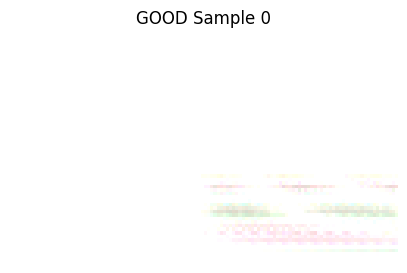

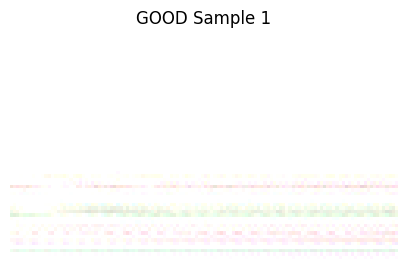

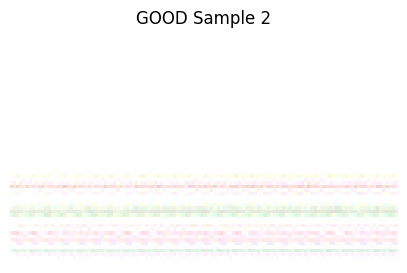

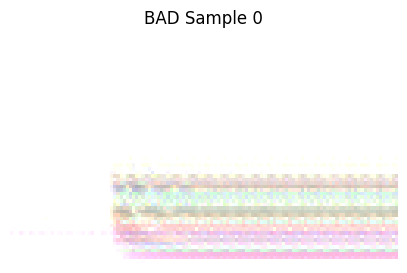

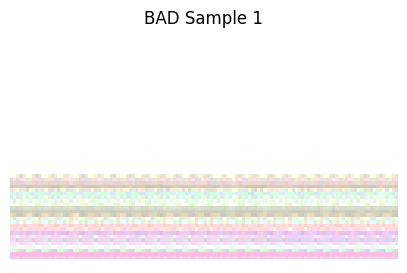

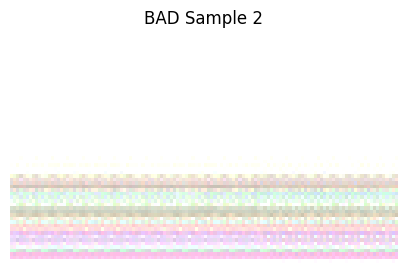

In [54]:

# Indizes holen
good_idx = np.where(y_label == 1)[0][:3]
bad_idx  = np.where(y_label == 0)[0][:3]

# zuerst GOOD
for i, idx in enumerate(good_idx):
    sample = X[idx]
    label = y_label[idx]

    x, y, z = sample

    specs = [
        create_spectrogram(x, FS, db_min, db_max),
        create_spectrogram(y, FS, db_min, db_max),
        create_spectrogram(z, FS, db_min, db_max)
    ]

    rgb = np.stack(specs, axis=-1)
    rgb = np.clip(rgb, 0, 1)
    rgb = np.flipud(rgb)

    plt.figure(figsize=(5, 3))
    plt.imshow(rgb, aspect='auto')
    plt.title(f"GOOD Sample {i}")
    plt.axis("off")
    plt.show()


# dann BAD
for i, idx in enumerate(bad_idx):
    sample = X[idx]
    label = y_label[idx]

    x, y, z = sample

    specs = [
        create_spectrogram(x, FS, db_min, db_max),
        create_spectrogram(y, FS, db_min, db_max),
        create_spectrogram(z, FS, db_min, db_max)
    ]

    rgb = np.stack(specs, axis=-1)
    rgb = np.clip(rgb, 0, 1)
    rgb = np.flipud(rgb)

    plt.figure(figsize=(5, 3))
    plt.imshow(rgb, aspect='auto')
    plt.title(f"BAD Sample {i}")
    plt.axis("off")
    plt.show()


In [15]:
X[3]

array([[ 0.02214812,  0.02306412,  0.00566012, ..., -0.01540788,
         0.02489612,  0.03130812],
       [ 0.03070806,  0.01938806, -0.01834394, ..., -0.07494194,
        -0.04475594, -0.00419394],
       [ 0.18732888,  0.17595988,  0.06908788, ..., -0.12532912,
        -0.04688012,  0.04862288]], shape=(3, 8000))

In [20]:
len(X[1][:])

3